# Libraries

In [17]:
import pandas as pd
import json
import datetime
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting Up the Battery and Market Configuration

In [18]:
battery_config = {
    'energy': 1,
    'power': 1,
    'cycle_limit': 2,
    'service_life': 10, 
    'efficiency': 0.95, 
    'maxSOC': 1, 
    'minSOC': 0, 
    'startSOC': 0.5,
    'DoD': 1, 
    'costs': 250  # costs in €/kWh
}

market_config = {
    'FCR': {'t_delivery': 4, 'power_share': 0.8, 'capture_rate': 6/6, 'capacity_share': 1}
}

# calculate additional battery parameters. Aging costs are based on initial invest
aging_costs = battery_config['costs'] * 1000 / (battery_config['service_life'] * battery_config['cycle_limit'] * 365)  # in €/MWh
battery_config['aging_costs'] = aging_costs

# Specifying the Date and the Market

In [19]:
day = '2024-09-30'
market = 'FCR'

# Getting the Prices for the Mentioned Date

In [20]:
folder_path = os.path.join('..','marketdata', 'fcr_data')
file_path = os.path.join(folder_path, rf'fcr_{pd.Timestamp(day).strftime("%Y-%m-%d")}.xlsx')

all_fcr_data = pd.read_excel(file_path, header=0, index_col=0)  # index is date
fcr_data = all_fcr_data[all_fcr_data['TENDER_NUMBER']==1]
prices = fcr_data['GERMANY_SETTLEMENTCAPACITY_PRICE_[EUR/MW]']
prices.index = pd.to_datetime(prices.index)

c:\Anaconda3\envs\247-env\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# Setting the Marketable Power for FCR

In [21]:
afrr_power_symmetric = min(battery_config['energy'] / 2, battery_config['power'])  # for symmetric aFRR bids
afrr_power_share = afrr_power_symmetric * market_config[market]['power_share']  # share of the battery power that is used for aFRR
market_config[market]['marketable_power'] = afrr_power_share

# Calulating Revenues

In [22]:
# calculate revenues for the whole day
market_config[market]['marketable_power'] = market_config[market]['power_share'] * battery_config['power']
fcr_revenue = prices *  market_config[market]['marketable_power']# in € per 4 hour slot
daily_profit = fcr_revenue.sum()  # total revenue for the day

# add the first and the 7th, the second and the 8th and so on
block_revenues = pd.Series(index=range(6), data=0.0)
for i in range(6):
    block_revenues[i] = fcr_revenue[i] 

# Saving the Results in a Dataframe

In [23]:
print(f"Daily profit for {market} on {day} is {daily_profit} EUR")

# Initialise result df
results_df_day = pd.DataFrame()
timestamp_of_15min = pd.date_range(start=day + ' 00:00', periods=96, freq='15min')
results_df_day = pd.DataFrame(columns=list(market_config.keys()), index=timestamp_of_15min)
results_df_day.index = results_df_day.index.tz_localize('Europe/Berlin')
  
for t in results_df_day.index:
    if t in pd.date_range(start=pd.Timestamp(day + ' 00:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 03:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, market] = block_revenues[0] / 16 * market_config[market]['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 04:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 07:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, market] = block_revenues[1] / 16 * market_config[market]['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 08:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 11:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, market] = block_revenues[2] / 16 * market_config[market]['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 12:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 15:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, market] = block_revenues[3] / 16 * market_config[market]['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 16:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 19:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, market] = block_revenues[4] / 16 * market_config[market]['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 20:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 23:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, market] = block_revenues[5] / 16 * market_config[market]['capture_rate']

Daily profit for FCR on 2024-09-30 is 360.31200000000007 EUR


# Visualise the Results

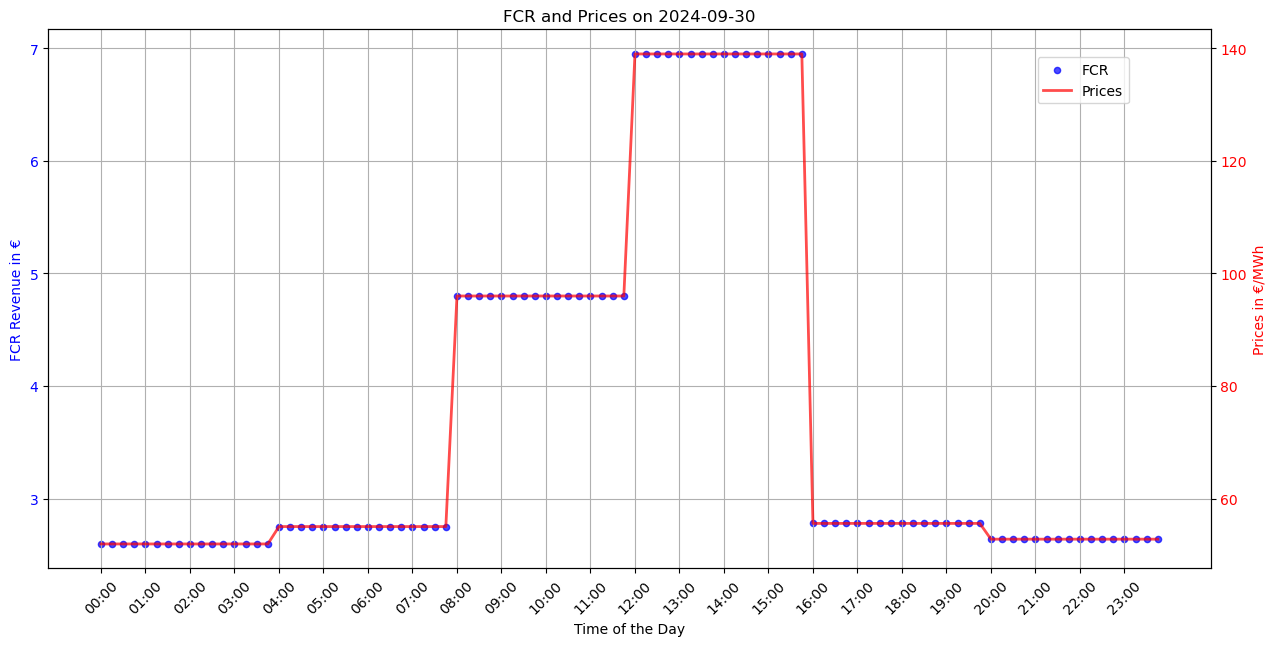

In [24]:
fig, ax1 = plt.subplots(figsize=(15, 7)) 

# replace negative values with 0
results_df_day['FCR'] = results_df_day['FCR'].apply(lambda x: 0 if x < 0 else x)

# Scatter plot
ax1.scatter(results_df_day.index, results_df_day['FCR'], color='b', alpha=0.7, s=20)
ax1.set_title('FCR and Prices on ' + str(results_df_day.index[0].date()))
ax1.set_xlabel('Time of the Day')
ax1.set_ylabel('FCR Revenue in €', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

# Set x-axis ticks to show hourly intervals
hourly_ticks = results_df_day.index[::4] 
ax1.set_xticks(hourly_ticks)
ax1.set_xticklabels(hourly_ticks.strftime('%H:%M'), rotation=45) 

# Add second y-axis for prices as a line
ax2 = ax1.twinx()
repeated_prices = prices.repeat(16).reset_index(drop=True)
repeated_prices.index = pd.date_range(start=f"{day} 00:00", end=f"{day} 23:59", freq="15T", tz="Etc/GMT-2").tolist()
ax2.plot(repeated_prices.index, repeated_prices, color='r', linestyle='-', linewidth=2, alpha=0.7)
ax2.set_ylabel('Prices in €/MWh', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Adding legends
fig.legend(['FCR', 'Prices'], loc="upper right", bbox_to_anchor=(0.85, 0.85))

plt.show()


In [25]:
repeated_prices = prices.repeat(16).reset_index(drop=True)
repeated_prices.index = pd.date_range(start=f"{day} 00:00", end=f"{day} 23:59", freq="15T", tz="Etc/GMT-2").tolist()

In [26]:
datetimes = pd.date_range(start=f"{day} 00:00", end=f"{day} 23:59", freq="15T").tolist()

In [27]:
repeated_prices.index = pd.date_range(start=f"{day} 00:00", end=f"{day} 23:59", freq="15T", tz="Etc/GMT-2").tolist()